**Importing Tensorflow**

In [1]:
import tensorflow as tf

In [2]:
import tensorflow_datasets as tfds
tfds.disable_progress_bar()

import math
import  numpy as np
import matplotlib.pyplot as plt

In [3]:
import logging # access the data inside tensorflow
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

**Importing Dataset**

In [4]:
dataset , metadata = tfds.load('fashion_mnist', as_supervised=True, with_info=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

In [5]:
print(dataset)

{'train': <_PrefetchDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>, 'test': <_PrefetchDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}


**loading Dataset**

In [6]:
class_name=['T-shirts','Trouser','Pullover','Dress','Coat','sandal','Shirt','Sneaker','Bag','Ankle Boot']

In [7]:
num_train_examples = metadata.splits['train'].num_examples
num_test_examples = metadata.splits['test'].num_examples
print("Number of training examples: {}".format(num_train_examples))
print("Number of test examples: {}".format(num_test_examples))

Number of training examples: 60000
Number of test examples: 10000


**Processing of dataset**

In [8]:
def normalize(images,labels):
  images = tf.cast(images, tf.float32)
  images /= 255
  return images, labels

  train_dataset = train_dataset.map(normalize)
  test_dataset = test_dataset.map(normalize)

  train_dataset = train_dataset.cache()# cache : memory storage
  test_dataset = test_dataset.cache()

**Exploring the processed dataset**

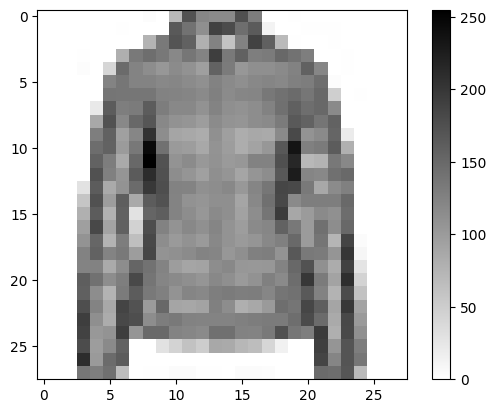

In [9]:
for image, label in test_dataset.take(2):
  break
image = image.numpy().reshape((28,28))

plt.figure()
plt.imshow(image, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

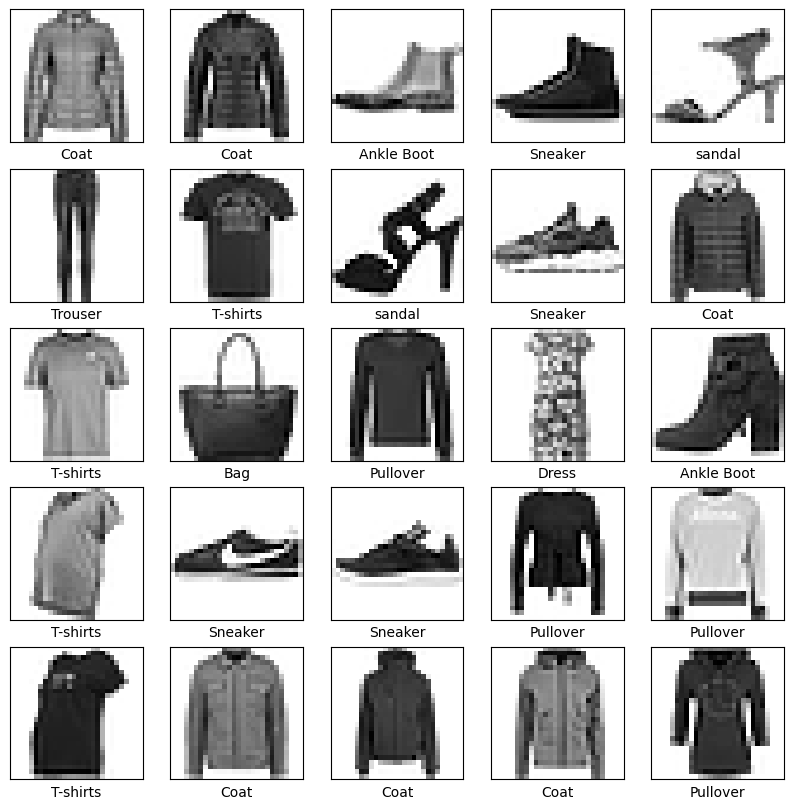

In [10]:
plt.figure(figsize=(10,10))
i=0
for (image, label) in test_dataset.take(25):
  image = image.numpy().reshape((28,28))
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(image, cmap=plt.cm.binary)
  plt.xlabel(class_name[label])
  i+=1
plt.show()

**Building Model**

In [11]:
model=tf.keras.Sequential([
  tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.relu,
                          input_shape=(28,28,1)),
 tf.keras.layers.MaxPooling2D((2,2), strides=2),
 tf.keras.layers.Conv2D(64, (3,3), padding='same', activation=tf.nn.relu),
tf.keras.layers.MaxPooling2D((2,2), strides=2),
 tf.keras.layers.Flatten(),
 tf.keras.layers.Dense(128, activation=tf.nn.relu),
tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compiling the model**

In [12]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

**Train the model**

In [13]:
Batch_size = 32
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(Batch_size)
test_dataset = test_dataset.batch(Batch_size)


In [14]:
model.fit(train_dataset, epochs=10, steps_per_epoch=math.ceil(num_train_examples/Batch_size))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 38ms/step - accuracy: 0.7956 - loss: 1.7324
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.8891 - loss: 0.3006
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 38ms/step - accuracy: 0.9041 - loss: 0.2613
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9120 - loss: 0.2333
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9200 - loss: 0.2155
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9259 - loss: 0.2005
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9329 - loss: 0.1817
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9394 - loss: 0.1654
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9431 - loss: 0.1521
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9470 - loss: 0.1434


**Evaluate accuracy**

In [15]:
test_loss, test_accuracy = model.evaluate(test_dataset, steps=math.ceil(num_test_examples
                                                                        /32))
print('Accuracy on test dataset:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9058 - loss: 0.3409
Accuracy on test dataset: 0.9065999984741211


**Predictions and Explorations**

In [16]:
for test_images, test_labels in test_dataset.take(1):
  test_images = test_images.numpy()
  test_labels = test_labels.numpy()
  predictions = model.predict(test_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


In [17]:
predictions.shape

(32, 10)

In [18]:
predictions[0]

array([3.05285312e-07, 1.09081175e-10, 5.68348356e-03, 7.09997749e-09,
       9.84088898e-01, 1.50235049e-13, 1.02270897e-02, 1.66522720e-12,
       8.76510029e-08, 1.31730196e-10], dtype=float32)

In [19]:
predictions[15]

array([4.6440223e-01, 7.2303979e-04, 4.3934789e-01, 2.4528893e-02,
       1.8708495e-02, 4.4109743e-07, 5.2266471e-02, 1.2628225e-10,
       2.2490070e-05, 1.4833786e-09], dtype=float32)

In [20]:
np.argmax(predictions[0])

np.int64(4)

In [21]:
test_labels[0]

np.int64(4)

In [24]:
def plot_image(i, predictions_array, true_labels, images):
  predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[...,0], cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_name[predicted_label],
                                100*np.max(predictions_array),
                                class_name[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array[i], true_label[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

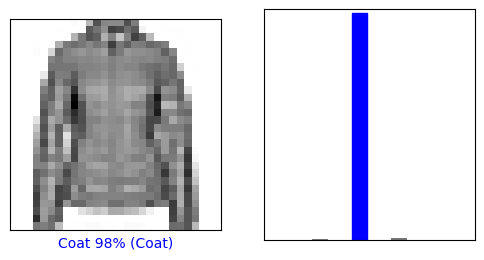

In [25]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions, test_labels)

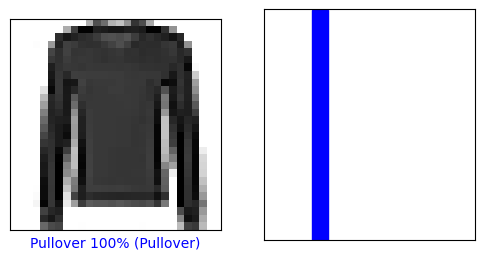

In [26]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions, test_labels)

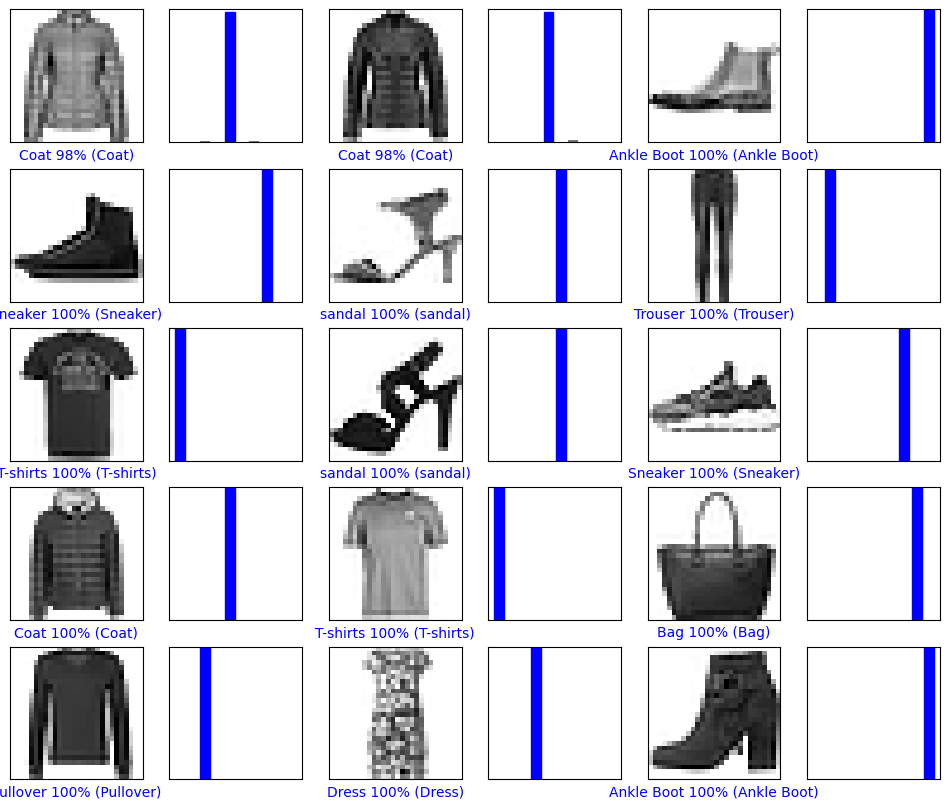

In [27]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions, test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions, test_labels)


In [28]:
img = test_images[0]

print(img.shape)

(28, 28, 1)


In [29]:
img = np.array([img])

print(img.shape)

(1, 28, 28, 1)


In [30]:
predictions_single = model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
[[3.0528449e-07 1.0908077e-10 5.6834733e-03 7.0999784e-09 9.8408902e-01
  1.5023508e-13 1.0227072e-02 1.6652306e-12 8.7650839e-08 1.3173021e-10]]


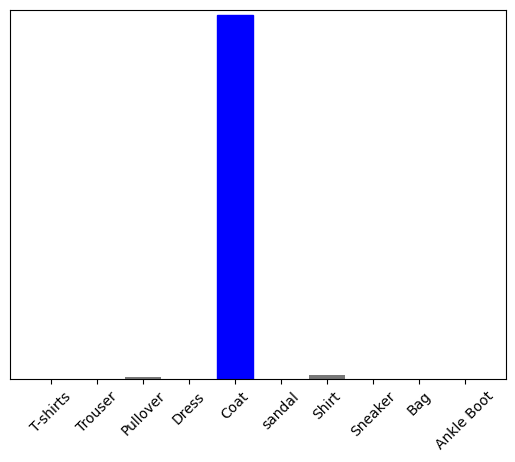

In [32]:
plot_value_array(0, predictions_single, test_labels)
_ = plt.xticks(range(10), class_name, rotation=45)

In [33]:
np.argmax(predictions_single[0])

np.int64(4)